In [1]:
import pandas as pd
df = pd.read_csv("IKEA_product_catalog.csv")
df

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country
0,10018194-Australia,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,3.3,140.0,none,True,https://www.ikea.com/au/en/p/ordning-dish-drai...,30.00,AUD,none,NONE,Australia
1,10018194-Austria,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.3,6.0,none,True,https://www.ikea.com/at/en/p/ordning-dish-drai...,27.99,EUR,none,NONE,Austria
2,10018194-Bahrain,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,1.0,1.0,none,True,https://www.ikea.com/bh/en/p/ordning-dish-drai...,9.50,BHD,none,NONE,Bahrain
3,10018194-Belgium,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/be/en/p/ordning-dish-drai...,29.99,EUR,none,NONE,Belgium
4,10018194-Canada,10018194,ORDNING,Dish drainer,"50x27x36 cm (19 5/8x10 5/8x14 1/8 "")","ORDNING Dish drainer, stainless steel, 19 5/8x...",kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/ca/en/p/ordning-dish-drai...,34.99,CAD,none,NONE,Canada
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401041,99931611-Serbia,99931611,MALM,"Okvir kreveta,vis. s 4 kut.odlag.",160x200 cm,"MALM Okvir kreveta,vis. s 4 kut.odlag., bela, ...",kreveti-i-duseci,kreveti,4.3,798.0,none,True,https://www.ikea.com/rs/sr/p/malm-okvir-krevet...,37999.00,RSD,none,NEW_LOWER_PRICE,Serbia
401042,99931611-Slovenia,99931611,MALM,"Post okvir, visok, s 4 predali",160x200 cm,"Bel okvir postelje MALM s preprostim, sodobnim...",postelje-in-posteljni-vlozki,cenovno-ugodne-postelje,4.3,798.0,none,True,https://www.ikea.com/si/sl/p/malm-post-okvir-v...,339.00,EUR,none,NEW_LOWER_PRICE,Slovenia
401043,99931625-Egypt,99931625,MALM,"Bed frame, high, w 4 storage boxes",140x200 cm,"MALM Bed frame, high, w 4 storage boxes, black...",beds-mattresses,beds,4.3,3.0,none,True,https://www.ikea.com/eg/en/p/malm-bed-frame-hi...,26295.00,EGP,none,NONE,Egypt
401044,99931625-Jordan,99931625,MALM,"Bed frame, high, w 4 storage boxes",140x200 cm,"MALM Bed frame, high, w 4 storage boxes, black...",beds-mattresses,beds,none,none,none,True,https://www.ikea.com/jo/en/p/malm-bed-frame-hi...,345.00,JOD,none,NONE,Jordan


In [2]:
df = df.drop_duplicates()
df = df.dropna()
len(df)

401046

In [3]:
df.currency.unique()

array(['AUD', 'EUR', 'BHD', 'CAD', 'CLP', 'COP', 'CZK', 'DKK', 'EGP',
       'HUF', 'INR', 'JPY', 'JOD', 'KWD', 'MYR', 'MXN', 'MAD', 'NZD',
       'NOK', 'OMR', 'PHP', 'PLN', 'QAR', 'RON', 'SAR', 'RSD', 'SGD',
       'KRW', 'SEK', 'CHF', 'THB', 'AED', 'GBP', 'USD'], dtype=object)

In [4]:
conversion_rates = {
    "EUR" :  1.18,
    "AUD" : 0.17,
    "BHD" : 2.66,
    "CAD" : 0.73,
    "CLP" : 0.0011,
    "COP" : 0.00027,
    "CZK" : 0.049,
    "DKK" : 0.16,
    "EGP" : 0.021,
    "HUF" : 0.0031,
    "INR" : 0.011,
    "JPY" : 0.0064,
    "JOD" : 1.41,
    "KWD" : 3.26,
    "MYR" : 0.26,
    "MXN" : 0.058,
    "MAD" : 0.11,
    "NZD" : 0.6,
    "NOK" : 0.11,
    "OMR" : 2.6,
    "PHP" : 0.017,
    "PLN" : 0.28,
    "QAR" : 0.28,
    "RON" : 0.23,
    "SAR" : 0.27,
    "RSD" : 0.01,
    "SGD" : 0.79,
    "KRW" : 0.00069,
    "SEK" : 0.11,
    "CHF" : 1.30,
    "THB" : 0.032,
    "AED" : 0.27,
    "GBP" : 1.35,
    "USD" : 1
}

In [5]:
df["conversion_rate"] = df.currency.map(conversion_rates)
df["Price in USD"] = df.price * df.conversion_rate
df["Price in USD"] = df["Price in USD"].round(2)
df

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country,conversion_rate,Price in USD
0,10018194-Australia,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,3.3,140.0,none,True,https://www.ikea.com/au/en/p/ordning-dish-drai...,30.00,AUD,none,NONE,Australia,0.170,5.10
1,10018194-Austria,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.3,6.0,none,True,https://www.ikea.com/at/en/p/ordning-dish-drai...,27.99,EUR,none,NONE,Austria,1.180,33.03
2,10018194-Bahrain,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,1.0,1.0,none,True,https://www.ikea.com/bh/en/p/ordning-dish-drai...,9.50,BHD,none,NONE,Bahrain,2.660,25.27
3,10018194-Belgium,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/be/en/p/ordning-dish-drai...,29.99,EUR,none,NONE,Belgium,1.180,35.39
4,10018194-Canada,10018194,ORDNING,Dish drainer,"50x27x36 cm (19 5/8x10 5/8x14 1/8 "")","ORDNING Dish drainer, stainless steel, 19 5/8x...",kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/ca/en/p/ordning-dish-drai...,34.99,CAD,none,NONE,Canada,0.730,25.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401041,99931611-Serbia,99931611,MALM,"Okvir kreveta,vis. s 4 kut.odlag.",160x200 cm,"MALM Okvir kreveta,vis. s 4 kut.odlag., bela, ...",kreveti-i-duseci,kreveti,4.3,798.0,none,True,https://www.ikea.com/rs/sr/p/malm-okvir-krevet...,37999.00,RSD,none,NEW_LOWER_PRICE,Serbia,0.010,379.99
401042,99931611-Slovenia,99931611,MALM,"Post okvir, visok, s 4 predali",160x200 cm,"Bel okvir postelje MALM s preprostim, sodobnim...",postelje-in-posteljni-vlozki,cenovno-ugodne-postelje,4.3,798.0,none,True,https://www.ikea.com/si/sl/p/malm-post-okvir-v...,339.00,EUR,none,NEW_LOWER_PRICE,Slovenia,1.180,400.02
401043,99931625-Egypt,99931625,MALM,"Bed frame, high, w 4 storage boxes",140x200 cm,"MALM Bed frame, high, w 4 storage boxes, black...",beds-mattresses,beds,4.3,3.0,none,True,https://www.ikea.com/eg/en/p/malm-bed-frame-hi...,26295.00,EGP,none,NONE,Egypt,0.021,552.20
401044,99931625-Jordan,99931625,MALM,"Bed frame, high, w 4 storage boxes",140x200 cm,"MALM Bed frame, high, w 4 storage boxes, black...",beds-mattresses,beds,none,none,none,True,https://www.ikea.com/jo/en/p/malm-bed-frame-hi...,345.00,JOD,none,NONE,Jordan,1.410,486.45


In [6]:
df.isna().sum()

unique_id               0
product_id              0
product_name            0
product_type            0
product_measurements    0
product_description     0
main_category           0
sub_category            0
product_rating          0
product_rating_count    0
badge                   0
online_sellable         0
url                     0
price                   0
currency                0
discount                0
sale_tag                0
country                 0
conversion_rate         0
Price in USD            0
dtype: int64

In [7]:
df.dtypes

unique_id                object
product_id                int64
product_name             object
product_type             object
product_measurements     object
product_description      object
main_category            object
sub_category             object
product_rating           object
product_rating_count     object
badge                    object
online_sellable            bool
url                      object
price                   float64
currency                 object
discount                 object
sale_tag                 object
country                  object
conversion_rate         float64
Price in USD            float64
dtype: object

In [8]:
df["product_rating_count"].unique().tolist()

['140.0',
 '6.0',
 '1.0',
 '543.0',
 '41.0',
 '16.0',
 '8.0',
 '158.0',
 '69.0',
 '4.0',
 '64.0',
 'none',
 '71.0',
 '24.0',
 '33.0',
 '9.0',
 '18.0',
 '14.0',
 '63.0',
 '36.0',
 '558.0',
 '156.0',
 '175.0',
 '398.0',
 '28.0',
 '12.0',
 '445.0',
 '83.0',
 '93.0',
 '2230.0',
 '29.0',
 '247.0',
 '946.0',
 '284.0',
 '31.0',
 '189.0',
 '75.0',
 '55.0',
 '465.0',
 '48.0',
 '181.0',
 '102.0',
 '766.0',
 '7.0',
 '23.0',
 '5.0',
 '2.0',
 '354.0',
 '679.0',
 '3.0',
 '46.0',
 '150.0',
 '45.0',
 '10.0',
 '297.0',
 '15.0',
 '27.0',
 '22.0',
 '65.0',
 '54.0',
 '32.0',
 '844.0',
 '40.0',
 '47.0',
 '126.0',
 '261.0',
 '105.0',
 '138.0',
 '30.0',
 '171.0',
 '109.0',
 '351.0',
 '119.0',
 '77.0',
 '112.0',
 '26.0',
 '61.0',
 '20.0',
 '210.0',
 '80.0',
 '1571.0',
 '37.0',
 '34.0',
 '85.0',
 '244.0',
 '207.0',
 '11.0',
 '91.0',
 '96.0',
 '44.0',
 '129.0',
 '111.0',
 '147.0',
 '783.0',
 '135.0',
 '60.0',
 '116.0',
 '51.0',
 '740.0',
 '110.0',
 '92.0',
 '198.0',
 '76.0',
 '215.0',
 '101.0',
 '35.0',
 '1602.

In [9]:
df = df[df.product_rating_count != "none"]

In [10]:
df.dtypes

unique_id                object
product_id                int64
product_name             object
product_type             object
product_measurements     object
product_description      object
main_category            object
sub_category             object
product_rating           object
product_rating_count     object
badge                    object
online_sellable            bool
url                      object
price                   float64
currency                 object
discount                 object
sale_tag                 object
country                  object
conversion_rate         float64
Price in USD            float64
dtype: object

In [11]:
df["product_rating_count"] = pd.to_numeric(df["product_rating_count"], errors = 'coerce')

/var/folders/qq/ks2t1rdj67sc37gvntd7qmfh0000gn/T/ipykernel_21490/4219696138.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["product_rating_count"] = pd.to_numeric(df["product_rating_count"], errors = 'coerce')


In [12]:
df = df.dropna(subset = ["product_rating_count"])

In [13]:
df["product_rating_count"] = df["product_rating_count"].astype(int)

In [14]:
df.dtypes

unique_id                object
product_id                int64
product_name             object
product_type             object
product_measurements     object
product_description      object
main_category            object
sub_category             object
product_rating           object
product_rating_count      int64
badge                    object
online_sellable            bool
url                      object
price                   float64
currency                 object
discount                 object
sale_tag                 object
country                  object
conversion_rate         float64
Price in USD            float64
dtype: object

In [15]:
df["product_rating"] = pd.to_numeric(df["product_rating"], errors = 'coerce')
df = df.dropna(subset = ["product_rating"])
df["product_rating_count"] = df["product_rating_count"].astype(float)

In [16]:
df_min_ratings = df[df.product_rating_count >= 50]

In [17]:
df_min_ratings.dtypes

unique_id                object
product_id                int64
product_name             object
product_type             object
product_measurements     object
product_description      object
main_category            object
sub_category             object
product_rating          float64
product_rating_count    float64
badge                    object
online_sellable            bool
url                      object
price                   float64
currency                 object
discount                 object
sale_tag                 object
country                  object
conversion_rate         float64
Price in USD            float64
dtype: object

In [18]:
df_sorted = df_min_ratings.sort_values(by="product_rating")

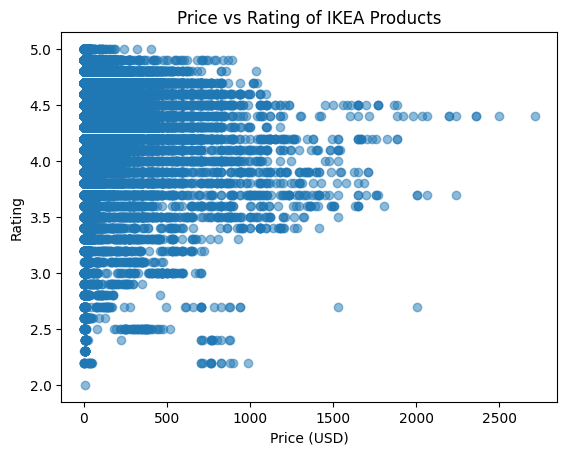

In [19]:
import matplotlib.pyplot as plt

plt.scatter(df_sorted['Price in USD'], df_sorted['product_rating'], alpha=0.5)
plt.xlabel("Price (USD)")
plt.ylabel("Rating")
plt.title("Price vs Rating of IKEA Products")
plt.show()

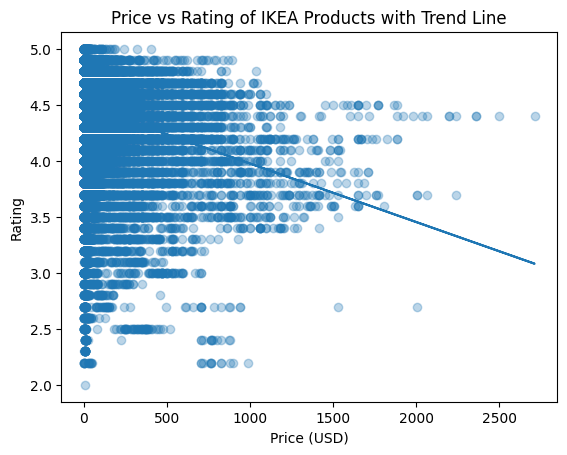

In [20]:
import numpy as np

x = df_sorted['Price in USD']
y = df_sorted['product_rating']

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y, alpha=0.3)
plt.plot(x, m*x + b)
plt.xlabel("Price (USD)")
plt.ylabel("Rating")
plt.title("Price vs Rating of IKEA Products with Trend Line")
plt.show()

In [21]:
corr = df_sorted['Price in USD'].corr(df_sorted['product_rating'])
print("Correlation:", corr)

Correlation: -0.21383877518118927


In [22]:
df_sorted.describe()

,product_id,product_rating,product_rating_count,price,conversion_rate,Price in USD
count,9.302100e+04,93021.000000,93021.000000,9.302100e+04,93021.000000,93021.000000
mean,4.562103e+07,4.463359,502.824964,5.807303e+03,0.630114,68.812033
std,2.919951e+07,0.347171,926.048263,4.776182e+04,0.521698,142.124149
min,2.850800e+04,2.000000,50.000000,1.900000e-01,0.000270,0.080000
25%,2.043939e+07,4.300000,92.000000,1.299000e+01,0.110000,5.950000
50%,4.062893e+07,4.600000,194.000000,5.999000e+01,0.600000,17.700000
75%,7.046636e+07,4.700000,480.000000,3.990000e+02,1.180000,64.890000
max,9.993161e+07,5.000000,10058.000000,3.799990e+06,2.660000,2712.820000


/var/folders/qq/ks2t1rdj67sc37gvntd7qmfh0000gn/T/ipykernel_21490/658921841.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sorted.groupby('price_bucket')['product_rating'].mean().plot(kind='bar')


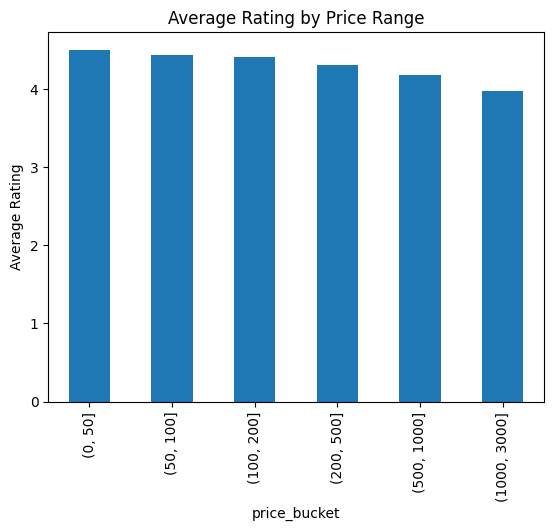

In [23]:
df_sorted['price_bucket'] = pd.cut(
    df_sorted['Price in USD'],
    bins=[0, 50, 100, 200, 500, 1000, 3000]
)

df_sorted.groupby('price_bucket')['product_rating'].mean().plot(kind='bar')
plt.title("Average Rating by Price Range")
plt.ylabel("Average Rating")
plt.show()

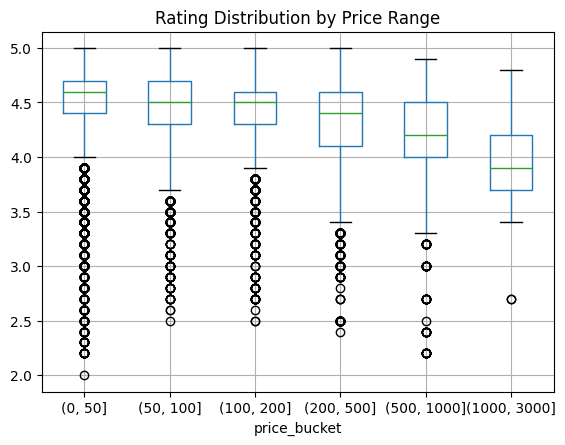

In [24]:
df_sorted.boxplot(column='product_rating', by='price_bucket')
plt.title("Rating Distribution by Price Range")
plt.suptitle("")
plt.show()


In [25]:
df_min_ratings['rating_norm'] = (df_min_ratings['product_rating'] - df_min_ratings['product_rating'].min()) / (df_min_ratings['product_rating'].max() - df_min_ratings['product_rating'].min())
df_min_ratings['price_norm'] = (df_min_ratings['Price in USD'] - df_min_ratings['Price in USD'].min()) / (df_min_ratings['Price in USD'].max() - df_min_ratings['Price in USD'].min())
df_min_ratings['value_score'] = df_min_ratings['rating_norm'] - df_min_ratings['price_norm']

/var/folders/qq/ks2t1rdj67sc37gvntd7qmfh0000gn/T/ipykernel_21490/949648466.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_min_ratings['rating_norm'] = (df_min_ratings['product_rating'] - df_min_ratings['product_rating'].min()) / (df_min_ratings['product_rating'].max() - df_min_ratings['product_rating'].min())
/var/folders/qq/ks2t1rdj67sc37gvntd7qmfh0000gn/T/ipykernel_21490/949648466.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_min_ratings['price_norm'] = (df_min_ratings['Price in USD'] - d

In [26]:
df_min_ratings.describe()["Price in USD"]

count    93021.000000
mean        68.812033
std        142.124149
min          0.080000
25%          5.950000
50%         17.700000
75%         64.890000
max       2712.820000
Name: Price in USD, dtype: float64

In [27]:
df_true_value = df_min_ratings[df_min_ratings["Price in USD"] >= 20]

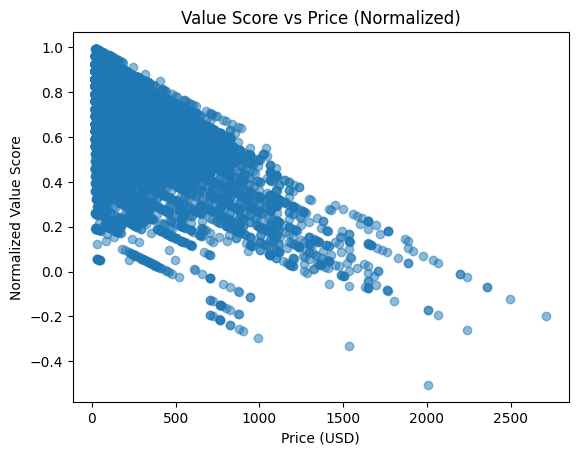

In [28]:
plt.scatter(df_true_value['Price in USD'], df_true_value['value_score'], alpha=0.5)
plt.xlabel("Price (USD)")
plt.ylabel("Normalized Value Score")
plt.title("Value Score vs Price (Normalized)")
plt.show()

In [29]:
top_value = df_true_value.sort_values('value_score', ascending=False).head(10)
top_value[['product_name', 'Price in USD', 'product_rating', 'value_score']]

,product_name,Price in USD,product_rating,value_score
53925,BLÅVINGAD,20.54,5.0,0.992458
281207,KÄLLARHALS,20.64,5.0,0.992421
85591,ÅRSTID,22.40,5.0,0.991772
20526,RODGERSIA,22.40,5.0,0.991772
126324,LIVLIG,22.40,5.0,0.991772
87260,BLÅHAJ,22.40,5.0,0.991772
28827,FLISAT,22.40,5.0,0.991772
371960,FLISAT,22.40,5.0,0.991772
71620,FLISAT,22.40,5.0,0.991772
308406,SKURUP,22.40,5.0,0.991772


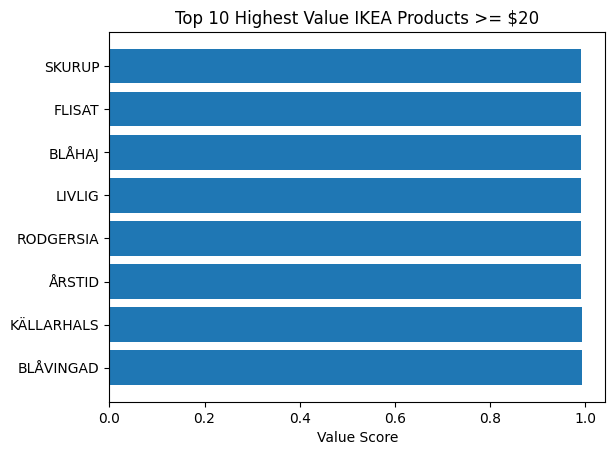

In [30]:
plt.barh(top_value['product_name'], top_value['value_score'])
plt.xlabel("Value Score")
plt.title("Top 10 Highest Value IKEA Products >= $20")
plt.show()

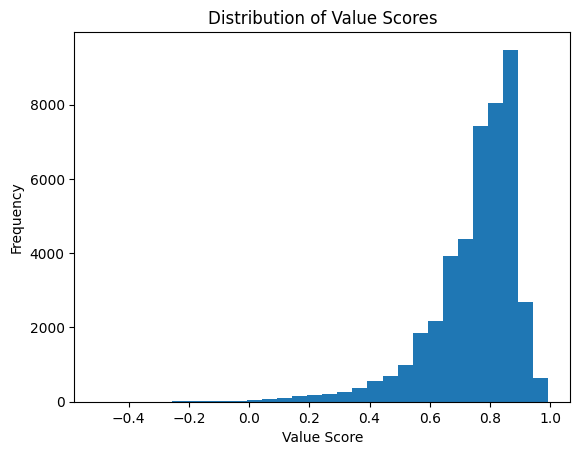

In [33]:
plt.hist(df_true_value['value_score'], bins=30)
plt.xlabel("Value Score")
plt.ylabel("Frequency")
plt.title("Distribution of Value Scores")
plt.show()

/var/folders/qq/ks2t1rdj67sc37gvntd7qmfh0000gn/T/ipykernel_21490/1654083070.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_true_value['price_bucket'] = pd.cut(
/var/folders/qq/ks2t1rdj67sc37gvntd7qmfh0000gn/T/ipykernel_21490/1654083070.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_true_value.groupby('price_bucket')['value_score'].mean().plot(kind='bar')


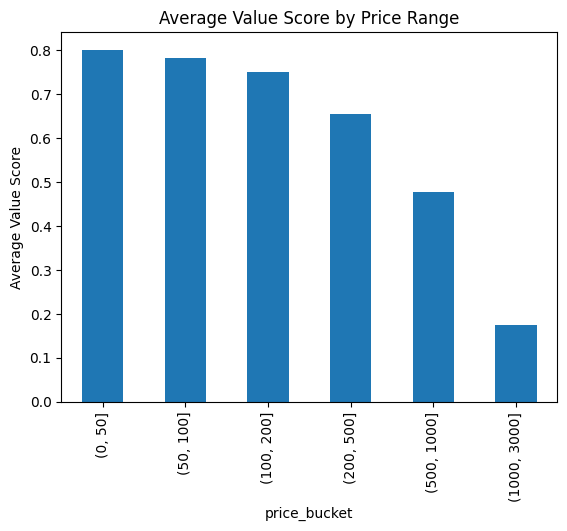

In [35]:
df_true_value['price_bucket'] = pd.cut(
    df_true_value['Price in USD'],
    bins=[0, 50, 100, 200, 500, 1000, 3000]
)

df_true_value.groupby('price_bucket')['value_score'].mean().plot(kind='bar')
plt.title("Average Value Score by Price Range")
plt.ylabel("Average Value Score")
plt.show()

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
threshold = df_true_value['value_score'].quantile(0.75)
df_true_value['high_value'] = (df_true_value['value_score'] >= threshold).astype(int)
features = ['Price in USD', 'product_rating_count']
X = df_true_value[features]
y = df_true_value['high_value']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/var/folders/qq/ks2t1rdj67sc37gvntd7qmfh0000gn/T/ipykernel_21490/2673360976.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_true_value['high_value'] = (df_true_value['value_score'] >= threshold).astype(int)


In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7537212449255751


In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86      6684
           1       0.00      0.00      0.00      2184

    accuracy                           0.75      8868
   macro avg       0.38      0.50      0.43      8868
weighted avg       0.57      0.75      0.65      8868



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [44]:
print("Coefficients:", model.coef_)

Coefficients: [[-0.01622859 -0.00010938]]
